Searching for Pristine Bragg Peak data files (PBP_*.csv)...
Successfully detected 35 energy simulation files.

Running L-BFGS-B optimization engine...

 FINAL PARTICLE COUNTS FOR 4 Gy SOBP
Energy Layer  1 (PBP_150.000000.csv):  72491692835 particles
Energy Layer  2 (PBP_149.044962.csv):  75995207050 particles
Energy Layer  3 (PBP_148.396135.csv):  78682847864 particles
Energy Layer  4 (PBP_147.745115.csv):  82620231577 particles
Energy Layer  5 (PBP_147.091879.csv):  86396484878 particles
Energy Layer  6 (PBP_146.436402.csv):  92618398711 particles
Energy Layer  7 (PBP_145.778657.csv): 100630730830 particles
Energy Layer  8 (PBP_145.118620.csv): 110405219221 particles
Energy Layer  9 (PBP_144.456263.csv): 118797620148 particles
Energy Layer 10 (PBP_143.791559.csv): 110143152007 particles
Energy Layer 11 (PBP_143.124480.csv):  77567555748 particles
Energy Layer 12 (PBP_142.454999.csv):  49041788051 particles
Energy Layer 13 (PBP_141.783086.csv):  50292183845 particles
Energy Layer 14 (P

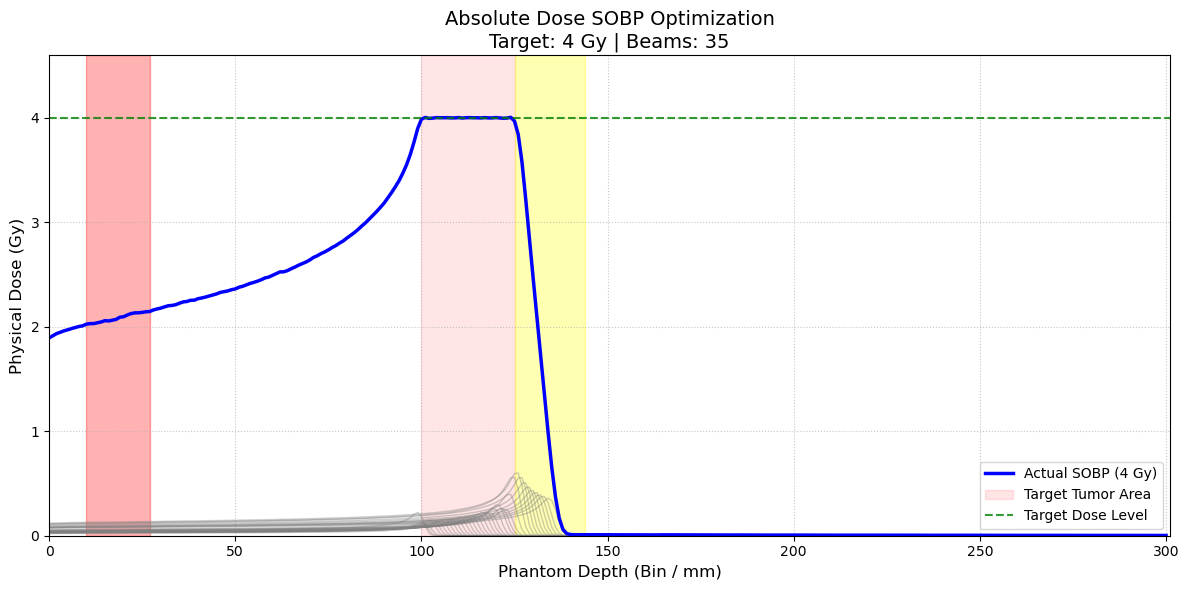

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import glob
import re

# ==========================================
# 1. TARGET SETTINGS & AUTO-LOAD FILES
# ==========================================
target_start = 100
target_end = 125

# --- PARAMETER BARU UNTUK DOSIS ABSOLUT ---
target_dose_Gy = 4
N_preliminary = 100000
# ------------------------------------------

print("Searching for Pristine Bragg Peak data files (PBP_*.csv)...")
raw_file_list = glob.glob("PBP_*.csv")

def get_energy(file_name):
    number = re.findall(r"\d+\.\d+|\d+", file_name)
    return float(number[0]) if number else 0.0

# Sort files from highest energy to lowest
file_list = sorted(raw_file_list, key=get_energy, reverse=True)

if not file_list:
    print("ERROR: No PBP_*.csv files found in this folder!")
else:
    print(f"Successfully detected {len(file_list)} energy simulation files.")

# ==========================================
# 2. DATA EXTRACTION & MATRIX CONSTRUCTION
# ==========================================
dose_matrix = []
for file in file_list:
    df = pd.read_csv(file, comment='#', header=None)
    dose_array = df.iloc[:, -1].values
    dose_matrix.append(dose_array)

min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]

# D adalah matriks dosis raw dari simulasi preliminary (untuk 10^5 partikel)
D = np.column_stack(dose_matrix_cropped)

# Normalisasi matriks untuk stabilitas L-BFGS-B (Mencegah mesin stuck)
D_max = np.max(D)
D_norm = D / D_max

# SOBP Target Line (Relatif 1.0)
t = np.zeros(min_len)
t[target_start:target_end + 1] = 1.0

# ==========================================
# 3. CUSTOM LOSS FUNCTION (L-BFGS-B)
# ==========================================
def loss_function(w, D_mat, target):
    prediction = D_mat.dot(w)

    tumor_area_dose = prediction[target_start:target_end+1]
    tumor_area_target = target[target_start:target_end+1]

    base_error = (tumor_area_dose - tumor_area_target)**2
    # Penalti lebih besar jika dosis melebihi target (overdose)
    penalty_error = np.where(tumor_area_dose > tumor_area_target, base_error * 10.0, base_error)

    smoothness_penalty = 0.001 * np.sum(w**2)

    return np.mean(penalty_error) + smoothness_penalty

# ==========================================
# 4. TPS OPTIMIZATION EXECUTION
# ==========================================
print("\nRunning L-BFGS-B optimization engine...")
w0 = np.ones(D_norm.shape[1]) * 0.1
bounds = [(0, None) for _ in range(D_norm.shape[1])]
result = minimize(loss_function, w0, args=(D_norm, t), method='L-BFGS-B', bounds=bounds)

best_w_rel = result.x

# ==========================================
# 5. CONVERSION TO EXACT PARTICLES FOR TARGET DOSE
# ==========================================
# Hitung profil dosis raw jika menggunakan bobot relatif
raw_combined_dose = D.dot(best_w_rel)

# Cari rata-rata dosis di area tumor dari kombinasi raw tersebut
avg_tumor_dose = np.mean(raw_combined_dose[target_start:target_end+1])

# Rumus Skala: (Target Dosis / Dosis Tumor Rata-rata) * N_preliminary
if avg_tumor_dose > 0:
    C_factor = (target_dose_Gy / avg_tumor_dose) * N_preliminary
    # Jumlah partikel aktual untuk setiap energi
    particle_weights = np.round(best_w_rel * C_factor).astype(int)
else:
    particle_weights = np.zeros(len(best_w_rel), dtype=int)

# ==========================================
# 6. FINAL SOBP VISUALIZATION (ABSOLUTE DOSE)
# ==========================================
# Hitung profil dosis final berdasarkan jumlah partikel aktual
d_per_history = D / N_preliminary
actual_dose_profile = d_per_history.dot(particle_weights)

depth_mm = np.arange(min_len)

plt.figure(figsize=(12, 6))

# Plot PBP curves individu (diskalakan dengan partikel aktual)
for i in range(len(particle_weights)):
    if particle_weights[i] > 0:
        plt.plot(depth_mm, d_per_history[:, i] * particle_weights[i], color='gray', alpha=0.4, linewidth=1.0)

print(f"\n{'='*65}")
print(f" FINAL PARTICLE COUNTS FOR {target_dose_Gy} Gy SOBP")
print(f"{'='*65}")
for i, weight in enumerate(particle_weights):
    print(f"Energy Layer {i+1:2d} ({file_list[i]}): {weight:12d} particles")
print(f"{'='*65}\n")

print(f"\n{'='*65}")
print(f" FINAL PARTICLE COUNTS FOR {target_dose_Gy} Gy SOBP")
print(f"{'='*65}")
for i, weight in enumerate(particle_weights):
    print(f"{weight:12d}")
print(f"{'='*65}\n")


# Plot Combined SOBP Curve
plt.plot(depth_mm, actual_dose_profile, 'b-', linewidth=2.5, label=f'Actual SOBP ({target_dose_Gy} Gy)')

# Highlight Target Tumor Area
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Target Tumor Area')

# Garis referensi target dosis
plt.axhline(y=target_dose_Gy, color='green', linestyle='--', alpha=0.8, label='Target Dose Level')

plt.title(f'Absolute Dose SOBP Optimization\nTarget: {target_dose_Gy} Gy | Beams: {len(file_list)}', fontsize=14)
plt.xlabel('Phantom Depth (Bin / mm)', fontsize=12)
plt.ylabel('Physical Dose (Gy)', fontsize=12)
plt.xlim([0, min_len])
# Y limit dilebihkan 15% dari target dosis agar grafik terlihat rapi
plt.ylim([0, target_dose_Gy * 1.15])
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

target_1a = 10
target_1b = 27

target_3a = 125
target_3b = 144

plt.axvspan(target_1a, target_1b, color='red', alpha=0.3, label='Target Enterence')
plt.axvspan(target_3a, target_3b, color='yellow', alpha=0.3, label='Target Distal Edge')


plt.tight_layout()
plt.show()